# 01 · Build the modeling table

**Output:** `data/processed/jobs_model.parquet` — one row per Tennessee job posting with
- the salary target (`log_pay`, `annual_mid`) and the disclosure treatment (`has_salary`),
- the survival target (`duration_days`, `event`; open postings are right-censored at `LAST_CHECKED`),
- employer / location / time / title features.

Also writes `salary_tn.parquet` (the ~375k salary rows for TN jobs) so the 2.5 GB salary file is only scanned once.
Set `SAMPLE_FRAC` (env var or edit below) to e.g. `0.05` for a quick test; sampled outputs get a `_sampleNN` suffix.

In [1]:
import sys, time
from pathlib import Path

ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from src import features as F

cfg = F.get_config()
SAMPLE_FRAC = cfg['SAMPLE_FRAC']      # set < 1.0 for a quick trial run (e.g. 0.05)
FORCE_REBUILD = cfg['FORCE_REBUILD']  # True = ignore cached outputs and recompute
SUFFIX = F.sample_suffix(cfg)
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 180)
print('root:', ROOT, '| SAMPLE_FRAC:', SAMPLE_FRAC, '| FORCE_REBUILD:', FORCE_REBUILD)

root: /home/jovyan/DataDive26 | SAMPLE_FRAC: 1.0 | FORCE_REBUILD: False


## 1. Load job records

In [2]:
t0 = time.time()
jobs_path = F.find_raw_file(F.JOBS_FILE, cfg)
jobs = F.load_jobs(jobs_path, sample_frac=SAMPLE_FRAC)
print(f'{len(jobs):,} job rows from {jobs_path.name} in {time.time()-t0:.0f}s')

filters = [('loaded', len(jobs))]
jobs = jobs[jobs['STATE'] == 'TN']
filters.append(('STATE == TN', len(jobs)))
jobs = jobs[jobs['CREATED'].notna() & jobs['LAST_CHECKED'].notna()]
filters.append(('has CREATED & LAST_CHECKED', len(jobs)))
assert jobs['JOB_HASH'].is_unique
jobs.head(3)

1,281,471 job rows from job-records_combined.csv.gz in 38s


,BASE_HASH,CITY,COMPANY_ID,COMPANY_NAME,COUNTRY,CREATED,DELETE_DATE,JOB_HASH,LAST_CHECKED,LAST_UPDATED,STATE,TITLE,UNMAPPED_LOCATION,URL,ZIP
0,104fb04ee3865bddd564238fcd3179b1,collierville,17354,FedEx Corp,USA,2025-03-05 02:26:00,2025-03-12 05:58:00,104fb04ee3865bddd564238fcd3179b1,2025-03-11 05:26:00,NaT,TN,Electronics Technician I,False,https://careers.fedex.com/electronics-technici...,38017
1,104fc977eaf83ba557a389f567274c27,germantown,37832,Acadia Healthcare Co Inc,USA,2025-03-11 13:02:00,2025-03-24 16:18:00,104fc977eaf83ba557a389f567274c27,2025-03-24 04:18:00,NaT,TN,Mobile Assessment Manager,False,https://non-corporate-acadiahealthcare.icims.c...,38138
2,104fde12c2d8ccf8d5bb7137e9996206,memphis,9609,White Cap Supply Holdings Inc,USA,2025-01-07 17:31:00,2025-01-13 19:29:00,104fde12c2d8ccf8d5bb7137e9996206,2025-01-11 19:16:00,NaT,TN,Driver - CDL,False,https://whitecap.wd1.myworkdayjobs.com/careers...,38103


## 2. Extract the salary rows for these jobs (cached)
Streams the salary CSV in 2M-row chunks and keeps only matching `JOB_HASH`es. Takes ~4–8 min the first time (longer from `.gz`).

In [3]:
sal_path = cfg['DATA_PROC'] / f'salary_tn{SUFFIX}.parquet'
if sal_path.exists() and not FORCE_REBUILD:
    sal = pd.read_parquet(sal_path)
    print(f'loaded cached {sal_path.name}: {len(sal):,} rows')
else:
    t0 = time.time()
    sal = F.extract_salary_for(F.find_raw_file(F.SALARY_FILE, cfg), jobs['JOB_HASH'])
    sal.to_parquet(sal_path, index=False)
    print(f'saved {sal_path.name} in {time.time()-t0:.0f}s')
sal = sal[sal['JOB_HASH'].isin(set(jobs['JOB_HASH']))]
print(f'share of jobs with a salary: {len(sal)/len(jobs):.1%}')
sal.head(3)

loaded cached salary_tn.parquet: 374,462 rows
share of jobs with a salary: 29.2%


,EXTRACTED_VALUE_HIGH,EXTRACTED_VALUE_LOW,JOB_HASH,NORMALIZED_ANNUAL_HIGH_USD,NORMALIZED_ANNUAL_LOW_USD,NORMALIZED_FREQUENCY,SALARY_DATE
0,NaN,17.06,70c429ac0622b280980b39a0b46b12a2,NaN,35484.8,hourly,2025-04-05
1,23.0,21.00,dac5de298e08abd995f03a915d337ad2,47840.0,43680.0,hourly,2026-06-08
2,59547.0,47637.00,55b6d20b63c71dd11c809b6162344820,59547.0,47637.0,yearly,2026-07-06


## 3. Build features and targets

In [4]:
t0 = time.time()
df = F.build_model_table(jobs, sal)
df = df[df['duration_days'] > 0]
filters.append(('duration > 0', len(df)))
df = F.finalize_types(df)
print(f'built {df.shape} in {time.time()-t0:.0f}s')
pd.DataFrame(filters, columns=['step', 'rows'])

built (1279291, 50) in 139s


,step,rows
0,loaded,1281471
1,STATE == TN,1281262
2,has CREATED & LAST_CHECKED,1281262
3,duration > 0,1279291


## 4. Sanity report

In [5]:
report = {
    'jobs': len(df),
    'has_salary share': df['has_salary'].mean(),
    'pay in 10k-500k (of salaried)': df.loc[df['has_salary'] == 1, 'pay_in_range'].mean(),
    'training rows for salary model (log_pay notna)': int(df['log_pay'].notna().sum()),
    'censored share (still open)': 1 - df['event'].mean(),
    'median duration, salaried (days)': df.loc[df['has_salary'] == 1, 'duration_days'].median(),
    'median duration, no salary (days)': df.loc[df['has_salary'] == 0, 'duration_days'].median(),
    'repost share': df['is_repost'].mean(),
    'unique titles': df['title_clean'].nunique(),
    'unique companies': df['COMPANY_ID'].nunique(),
    'unique ATS domains': df['ats_domain'].nunique(),
    'CREATED range': f"{df['CREATED'].min():%Y-%m-%d} .. {df['CREATED'].max():%Y-%m-%d}",
}
pd.Series(report, name='value').to_frame()

,value
jobs,1279291
has_salary share,0.292708
pay in 10k-500k (of salaried),0.999589
training rows for salary model (log_pay notna),374305
censored share (still open),0.058729
"median duration, salaried (days)",20.29375
"median duration, no salary (days)",26.125
repost share,0.087455
unique titles,319641
unique companies,6778


In [6]:
print(df['pay_frequency'].value_counts(), '\n')
print(df['created_quarter'].value_counts().sort_index(), '\n')
print(df['ats_domain'].value_counts().head(15))

pay_frequency
none         904832
hourly       245062
yearly       117092
monthly        5665
weekly         5514
daily           964
bi-weekly       162
Name: count, dtype: int64 

created_quarter
2024Q1    126151
2024Q2    125618
2024Q3    123020
2024Q4    107935
2025Q1    112686
2025Q2    111182
2025Q3    114536
2025Q4    106428
2026Q1    114711
2026Q2    125937
2026Q3    111087
Name: count, dtype: int64 

ats_domain
myworkdayjobs.com      129765
icims.com               98203
smartrecruiters.com     56164
oraclecloud.com         54183
ultipro.com             52086
jobappnetwork.com       46171
hcshiring.com           36093
hcahealthcare.com       26938
adp.com                 23507
walgreens.com           18340
dayforcehcm.com         17313
usajobs.gov             17214
tacobell.com            14970
paycomonline.net        14800
taleo.net               14164
Name: count, dtype: int64


In [7]:
# Disclosure rate by top title flags / quarter (first look at confounding for Phase 5)
flag_cols = [c for c in df.columns if c.startswith('title_') and df[c].dtype == 'int8' and c != 'title_level']
rows = [(c, int(df[c].sum()), df.loc[df[c] == 1, 'has_salary'].mean()) for c in flag_cols]
display(pd.DataFrame(rows, columns=['flag', 'n', 'salary disclosed share']).sort_values('n', ascending=False))
df.groupby('created_quarter', observed=True)['has_salary'].mean().rename('disclosure rate').to_frame().T

,flag,n,salary disclosed share
5,title_assistant,191343,0.260783
2,title_manager,153802,0.271128
8,title_nurse,125735,0.144956
6,title_part_time,99744,0.297441
1,title_lead,69060,0.371648
0,title_senior,47518,0.388253
9,title_driver,45661,0.413854
4,title_entry,28519,0.377888
3,title_director,27585,0.257785
10,title_has_dollar,20837,0.308922


created_quarter,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2,2026Q3
disclosure rate,0.258333,0.263983,0.297626,0.275277,0.292592,0.292439,0.308872,0.316467,0.317328,0.338804,0.258995


/tmp/ipykernel_720/2354727542.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); fig.savefig(cfg['FIG_DIR'] / f'01_overview{SUFFIX}.png', dpi=150); plt.show()


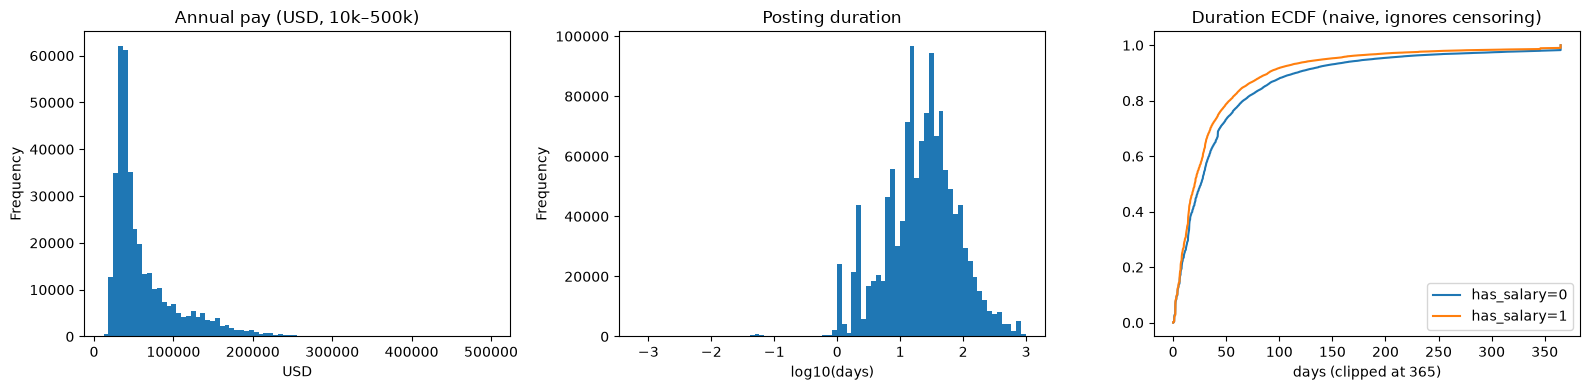

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df.loc[df['pay_in_range'], 'annual_mid'].plot.hist(bins=80, ax=axes[0])
axes[0].set(title='Annual pay (USD, 10k–500k)', xlabel='USD')
np.log10(df['duration_days']).plot.hist(bins=80, ax=axes[1])
axes[1].set(title='Posting duration', xlabel='log10(days)')
for flag, g in df.groupby('has_salary'):
    s = np.sort(g['duration_days'].clip(upper=365).to_numpy())
    axes[2].plot(s, np.arange(1, len(s) + 1) / len(s), label=f'has_salary={flag}')
axes[2].set(title='Duration ECDF (naive, ignores censoring)', xlabel='days (clipped at 365)')
axes[2].legend()
plt.tight_layout(); fig.savefig(cfg['FIG_DIR'] / f'01_overview{SUFFIX}.png', dpi=150); plt.show()

## 5. Save

In [9]:
out_path = cfg['DATA_PROC'] / f'jobs_model{SUFFIX}.parquet'
df.to_parquet(out_path, index=False)
t0 = time.time()
check = pd.read_parquet(out_path)
print(f'saved {out_path.name}: {check.shape}, {out_path.stat().st_size/1e6:.0f} MB, reload {time.time()-t0:.1f}s')
check.dtypes.value_counts()

saved jobs_model.parquet: (1279291, 50), 189 MB, reload 2.3s


int8              19
float64           10
string[python]     4
datetime64[ns]     4
int16              3
category           1
category           1
bool               1
category           1
category           1
category           1
category           1
category           1
category           1
int32              1
Name: count, dtype: int64